In [1]:
import numpy as np
import matplotlib.pyplot as plt



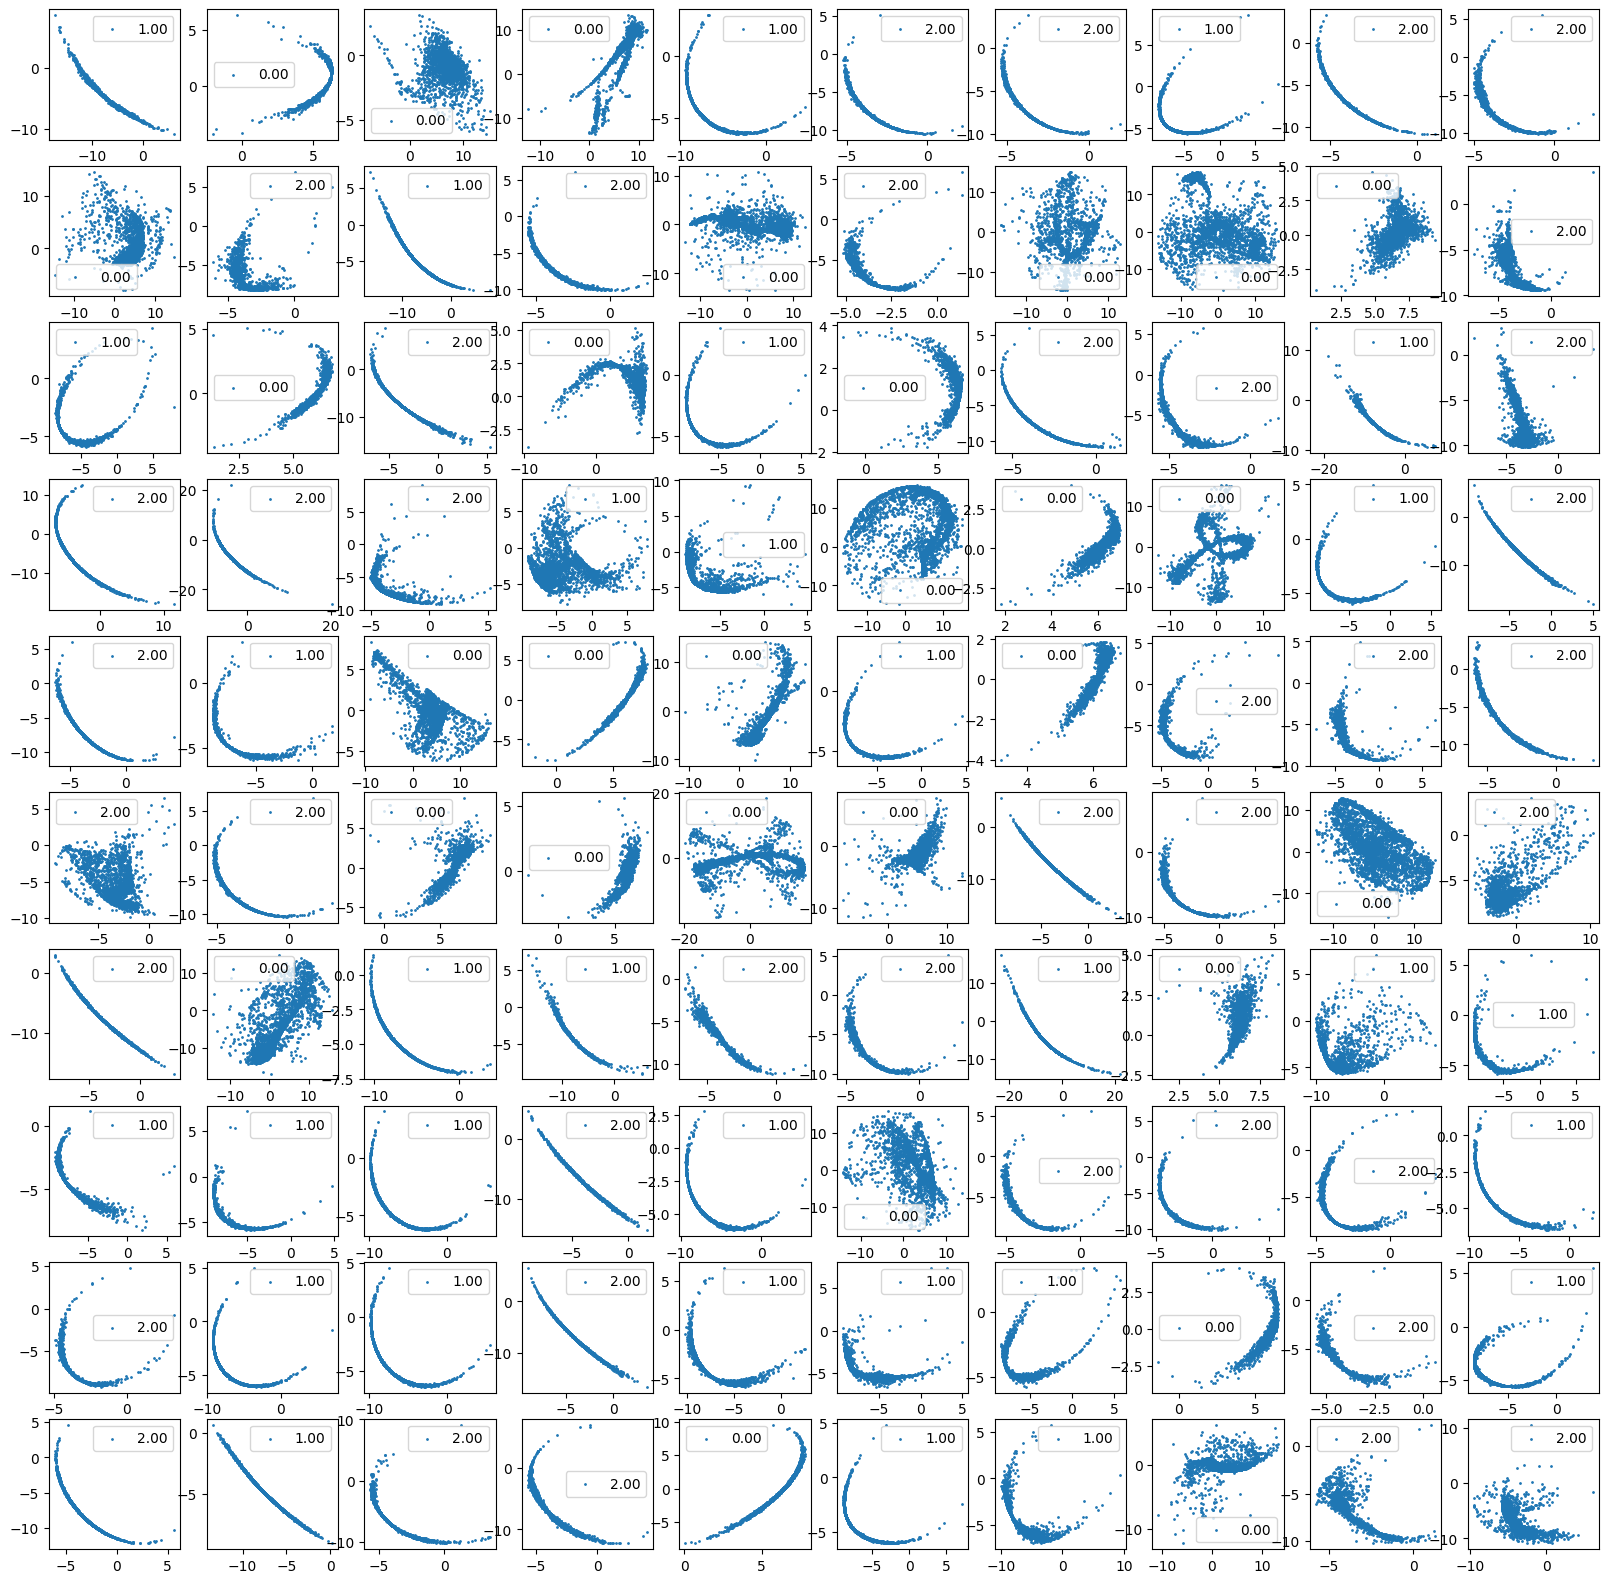

In [2]:
fig = plt.figure(figsize=(20, 20))
for idx, i in enumerate(range(300, 400)):
    data = np.load(f'../data/streams/data_streamax/data_streamax_1/simulation_{i}.npz')
    sim_data = data['sim_data_carthesian']

    ax = fig.add_subplot(10, 10, idx+1)
    ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['j'][0]:.2f}")
    # ax.set_xlim(-20, 20)
    # ax.set_ylim(-20, 20)
    ax.legend()

In [3]:
data['j'].shape

(1,)

Text(0.5, 0, '$V_r$')

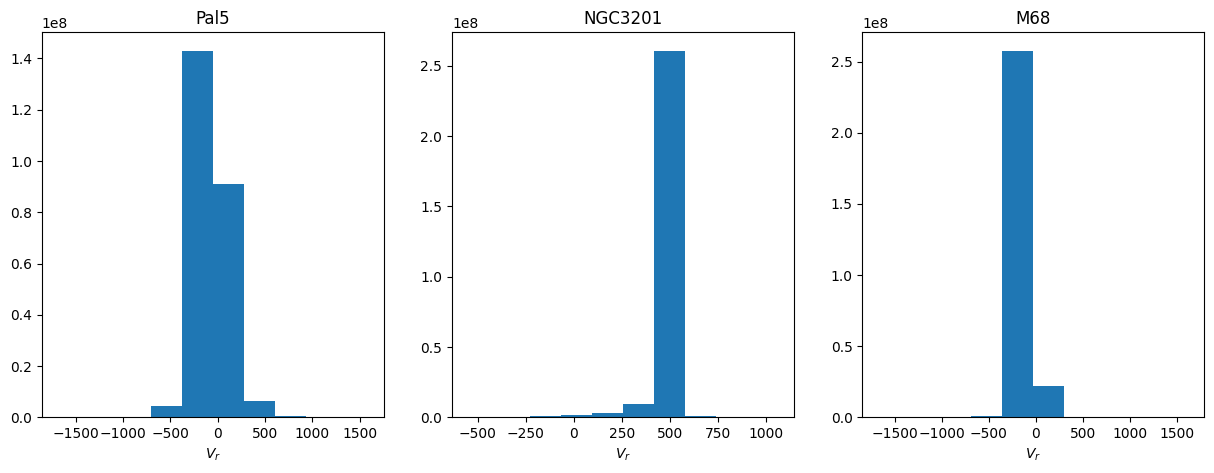

In [4]:
data = np.load(f'../data/streams/data_streamax/training_data_1000000.npz')
multistream_test_set = data['sim_data_projected']
j = data['j'].reshape(-1,)

# Observational windows
obs_windows = {
    0: {  # Pal5
        "ra_min": 220.98008280733634,
        "ra_max": 245.89465019770668,
        "dec_min": -10.644267714585839,
        "dec_max": 9.279576254116762,
    },
    1: {  # NGC3201
        "ra_min": 42.29847920913508,
        "ra_max": 178.36142433209437,
        "dec_min": -47.79545565626234,
        "dec_max": 20.812029301121846,
    },
    2: {  # M68
        "ra_min": 189.73694638139526,
        "ra_max": 273.48942253688114,
        "dec_min": -47.32109546202406,
        "dec_max": 66.52056055901161,
    }
}

# Example: create mask for Pal5 (j==0)
j = data['j'].reshape(-1,)
ra = data['sim_data_projected'][:, :, 0]  # shape: (n_sim, n_stars)
dec = data['sim_data_projected'][:, :, 1]

masks = {}
for stream_idx, win in obs_windows.items():
    # mask shape: (n_sim, n_stars)
    masks[stream_idx] = (
        (ra >= win["ra_min"]) & (ra <= win["ra_max"]) &
        (dec >= win["dec_min"]) & (dec <= win["dec_max"]) &
        (j[:, None] == stream_idx)
    )

# Usage example: mask for Pal5
observational_mask_pal5 = masks[0]
observational_mask_ngc3201 = masks[1]
observational_mask_m68 = masks[2]

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, )
ax1.hist(multistream_test_set[:, :, 5][observational_mask_pal5], )
ax1.set_title("Pal5")
ax1.set_xlabel('$V_r$')


ax2 = fig.add_subplot(132, )
ax2.hist(multistream_test_set[:, :, 5][observational_mask_ngc3201],)
ax2.set_title("NGC3201")
ax2.set_xlabel('$V_r$')


ax3 = fig.add_subplot(133, )
ax3.hist(multistream_test_set[:, :, 5][observational_mask_m68],)
ax3.set_title("M68")
ax3.set_xlabel('$V_r$')


In [5]:
pal5stars = multistream_test_set[:, :, 5][observational_mask_pal5]
ngc3201stars = multistream_test_set[:, :, 5][observational_mask_ngc3201]
m68stars = multistream_test_set[:, :, 5][observational_mask_m68]

mean_pal5 = np.mean(pal5stars)
mean_ngc3201 = np.mean(ngc3201stars)
mean_m68 = np.mean(m68stars)
print(f"Mean $V_r$ for Pal5: {mean_pal5:.2f}")
print(f"Mean $V_r$ for NGC3201: {mean_ngc3201:.2f}")
print(f"Mean $V_r$ for M68: {mean_m68:.2f}")

std_pal5 = np.std(pal5stars)
std_ngc3201 = np.std(ngc3201stars)
std_m68 = np.std(m68stars)
print(f"Std $V_r$ for Pal5: {std_pal5:.2f}")
print(f"Std $V_r$ for NGC3201: {std_ngc3201:.2f}")
print(f"Std $V_r$ for M68: {std_m68:.2f}")

min_pal5, max_pal5 = np.min(pal5stars), np.max(pal5stars)
min_ngc3201, max_ngc3201 = np.min(ngc3201stars), np.max(ngc3201stars)
min_m68, max_m68 = np.min(m68stars), np.max(m68stars)
print(f"Min/Max $V_r$ for Pal5: {min_pal5:.2f}/{max_pal5:.2f}")
print(f"Min/Max $V_r$ for NGC3201: {min_ngc3201:.2f}/{max_ngc3201:.2f}")
print(f"Min/Max $V_r$ for M68: {min_m68:.2f}/{max_m68:.2f}")

Mean $V_r$ for Pal5: -51.76
Mean $V_r$ for NGC3201: 479.98
Mean $V_r$ for M68: -95.42
Std $V_r$ for Pal5: 137.04
Std $V_r$ for NGC3201: 71.38
Std $V_r$ for M68: 65.70
Min/Max $V_r$ for Pal5: -1696.03/1588.26
Min/Max $V_r$ for NGC3201: -553.94/1066.65
Min/Max $V_r$ for M68: -1676.98/1621.69


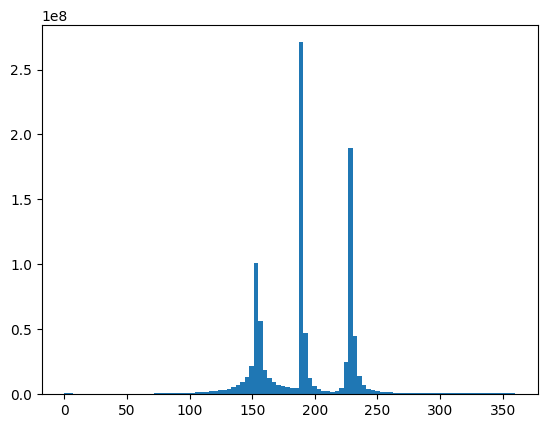

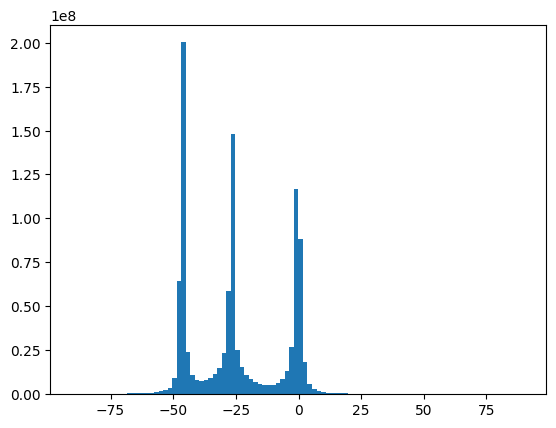

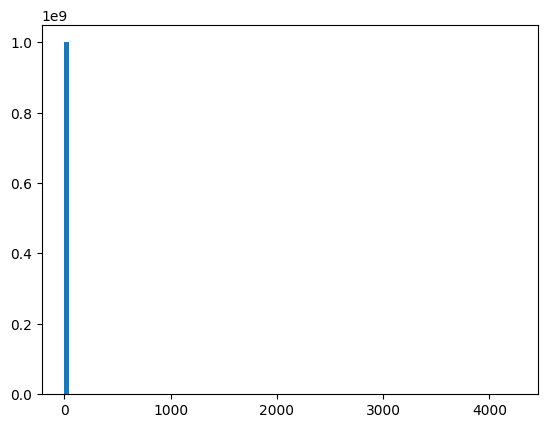

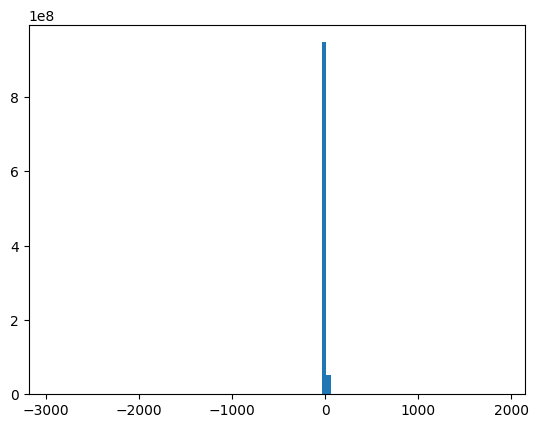

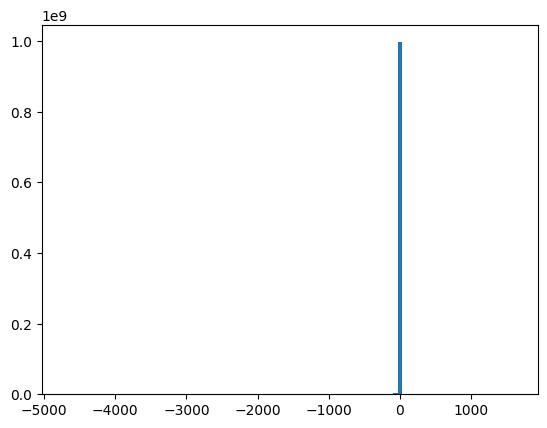

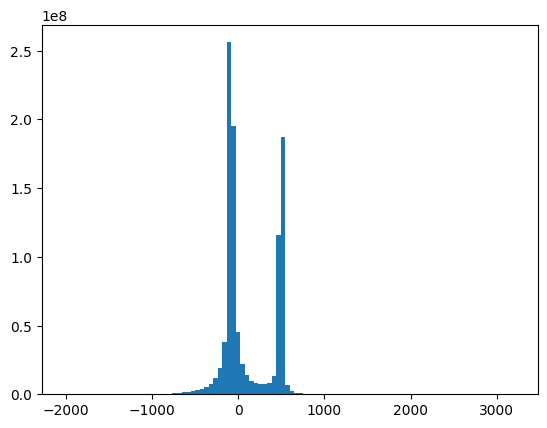

In [8]:
for i in range(6):
    plt.hist(data['sim_data_projected'][:,:, i].flatten(), bins=100)
    plt.show()


In [9]:
for i in range(6):
    sim_data = data['sim_data_projected'][:,:, i].flatten()
    sim_data = sim_data[~np.isnan(sim_data)]
    print(np.min(sim_data), np.max(sim_data))

2.0262557e-06 360.0
-89.984055 89.95658
0.031283405 4241.539
-2947.5588 1903.0648
-4716.3735 1621.7828
-2016.4514 3213.0002


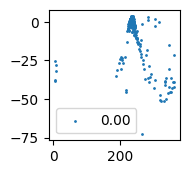

In [ ]:
# fig = plt.figure(figsize=(20, 20))
# for idx, i in enumerate(range(0, 1)):
#     sim_data = data['sim_data_projected'][idx]

#     ax = fig.add_subplot(10, 10, idx+1)
#     ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['j'][idx][0]:.2f}")
#     # ax.set_xlim(-20, 20)
#     # ax.set_ylim(-20, 20)
#     ax.legend()

In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# import glob

# # Map j index to stream name
# target_streams = {
#     "Pal5": 0,
#     "NGC3201": 1,
#     "M68": 2
# }
# # Reverse mapping for convenience
# j_to_stream = {v: k for k, v in target_streams.items()}

# # 1. Gather all simulation files
# sim_files = sorted(glob.glob('../data/streams/data_streamax/simulation_*.npz'))

# # 2. Construct sim_data: {stream_name: [sim_result, ...]}
# sim_data = {name: [] for name in target_streams}
# for fname in sim_files:
#     data = np.load(fname)
#     j = int(data['j'])
#     stream_name = j_to_stream.get(j, None)
#     if stream_name is None:
#         continue
#     sim_result = {
#         'x': data['sim_data_carthesian'][:, 0],
#         'y': data['sim_data_carthesian'][:, 1],
#         'z': data['sim_data_carthesian'][:, 2],
#         'ra': data['sim_data_projected'][:, 0],
#         'dec': data['sim_data_projected'][:, 1]
#     }
#     sim_data[stream_name].append(sim_result)

# # 3. Plotting
# for stream_name, sim_list in sim_data.items():
#     n_sim = len(sim_list)
#     if n_sim == 0:
#         continue
#     fig, axes = plt.subplots(3, n_sim, figsize=(4*n_sim, 12), squeeze=False)
#     fig.suptitle(f"Simulations for {stream_name}", fontsize=16)
#     for i, sim in enumerate(sim_list):
#         axes[0, i].scatter(sim['x'], sim['y'], s=1)
#         axes[0, i].set_xlabel('x')
#         axes[0, i].set_ylabel('y')
#         axes[0, i].set_title(f'Sim {i+1}')
#         axes[1, i].scatter(sim['x'], sim['z'], s=1)
#         axes[1, i].set_xlabel('x')
#         axes[1, i].set_ylabel('z')
#         axes[2, i].scatter(sim['ra'], sim['dec'], s=1)
#         axes[2, i].set_xlabel('ra')
#         axes[2, i].set_ylabel('dec')
#     plt.tight_layout(rect=[0, 0, 1, 0.96])
#     plt.show()